In [1]:
from torchvision import datasets
import torch
data_folder = '^/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


In [2]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

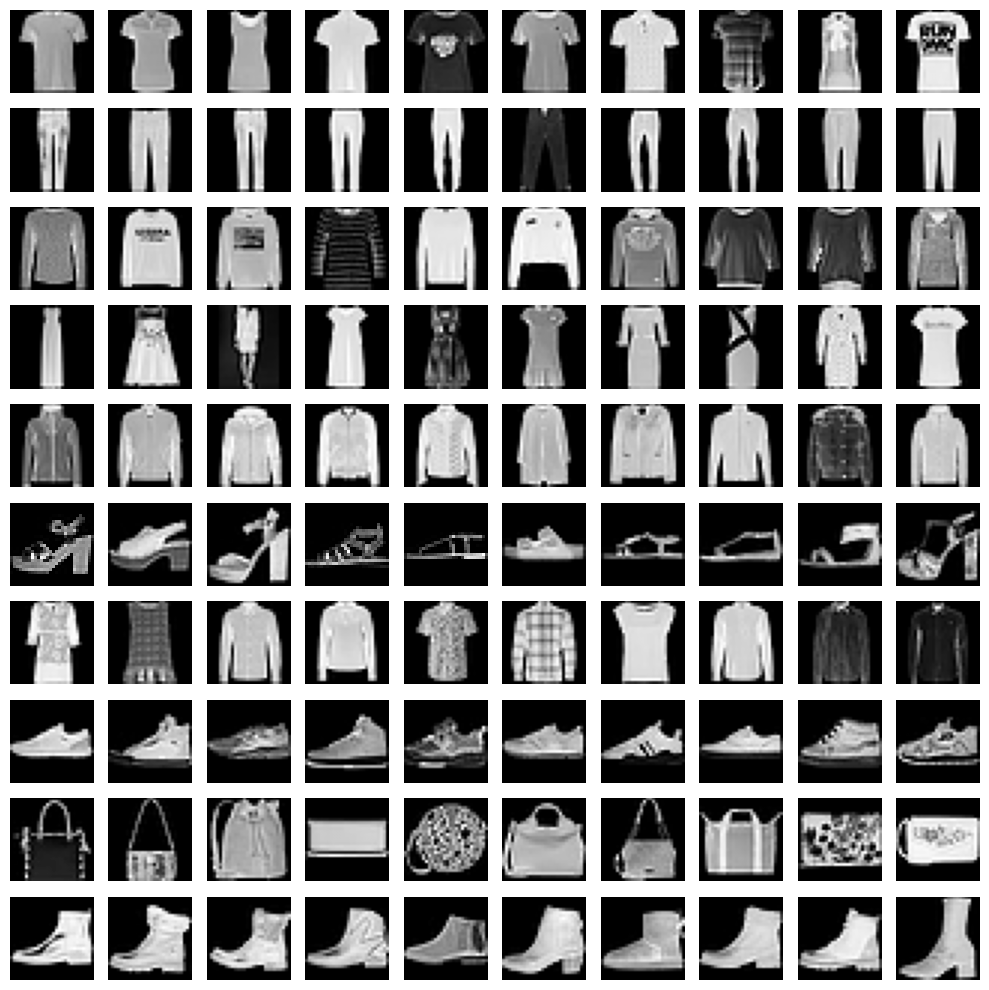

In [4]:
R, C = len(tr_targets.unique()), 10  # R é o numero de classes distintas e c exemplos por classe
fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
  label_x_rows = np.where(tr_targets == label_class)[0]  # pega os índices de todas as imagens dessa classe
  for plot_cell in plot_row:
    plot_cell.grid(False); plot_cell.axis('off')
    ix = np.random.choice(label_x_rows)  # imagem aleatoria de uma classe
    x, y = tr_images[ix], tr_targets[ix]
    plot_cell.imshow(tr_images[ix], cmap='gray')
plt.tight_layout()  # grade pra visualizar exemplos de cada classe do dataset

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from torchvision import datasets

In [7]:
class FMNISTDataset(Dataset):
  def __init__(self,x,y):
    x = x.float()
    x = x.view(-1, 28*28)  # achata cada imagem
    self.x, self.y = x, y
  def __getitem__(self, idx):
    x, y = self.x[idx], self.y[idx]
    return x.to(device), y.to(device)
  def __len__(self):
    return len(self.x)

In [8]:
def get_data(): # conjunto de dados é então carregados em um DataLoader
  train = FMNISTDataset(tr_images, tr_targets)
  return DataLoader(train, batch_size=128, shuffle=True)
  return trn_dl

## Training the Model

In [9]:
#Define um modelo de rede neural
from torch.optim import SGD
def get_model():
    # cria uma rede sequencial
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(), #função de ativação ReLU
        nn.Linear(1000, 10)).to(device) #camada de saída com 10 classes
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2) # otimizador
    return model, loss_fn, optimizer

In [11]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [12]:
def train_batch(x, y, model, opt, loss_fn):
  model.train()
  prediction = model(x)
  batch_loss = loss_fn(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()


In [13]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model() # cria o modelo

In [14]:
# inicializa listas de loss e acuracia
losses, accuracies = [], []
for epoch in range(5): # for de 5 epocas
    print(epoch)
    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)): # percorre todos os lotes
      #em cada lote de dados, o modelo é treinado e a perda e a acurácia são registradas
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)


0
1
2
3
4


/tmp/ipykernel_4567/3665355470.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


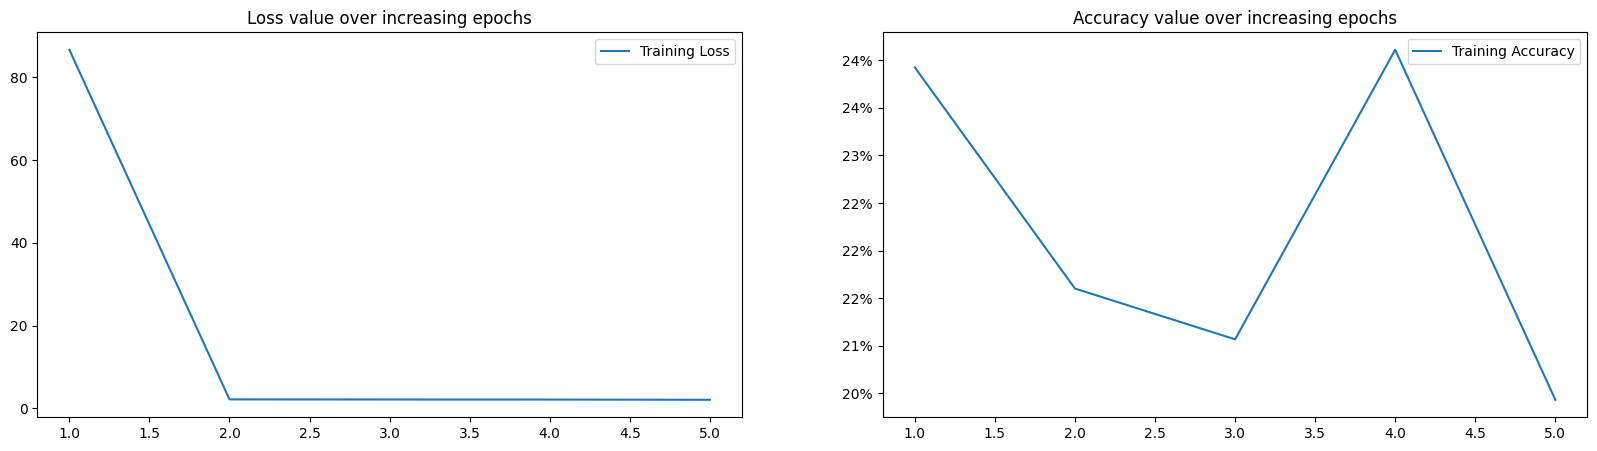

In [15]:
epochs = np.arange(5) + 1 # cria um array de 1 a 5
plt.figure(figsize=(20, 5)) # cria um figura de 20 x 5
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
# formata o eixo Y para exibir valores
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
#A perda diminui e a acurácia aumenta conforme o numero de épocas aumenta, que indica que o modelo tá aprendendo com os dados
